In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("SeoulBikeData.csv", encoding="cp1252")

df.head()

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes


In [3]:
print(df[["Temperature(°C)", "Rented Bike Count"]].head())
print(df[["Temperature(°C)", "Rented Bike Count"]].isnull().sum())

   Temperature(°C)  Rented Bike Count
0             -5.2                254
1             -5.5                204
2             -6.0                173
3             -6.2                107
4             -6.0                 78
Temperature(°C)      0
Rented Bike Count    0
dtype: int64


In [4]:
X = df[["Temperature(°C)"]].values
y = df["Rented Bike Count"].values.reshape(-1, 1)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
X_train_gd = np.c_[np.ones((len(X_train_scaled), 1)), X_train_scaled]
X_test_gd = np.c_[np.ones((len(X_test_scaled), 1)), X_test_scaled]

In [8]:
theta = np.zeros((2, 1))

print(theta)

[[0.]
 [0.]]


In [9]:
learning_rate = 0.01
epochs = 5000

loss_history = []

In [10]:
m = len(y_train)

for i in range(epochs):

    predictions = X_train_gd @ theta

    error = predictions - y_train

    loss = np.mean(error ** 2) / 2
    loss_history.append(loss)

    gradient = (X_train_gd.T @ error) / m

    theta = theta - learning_rate * gradient

In [11]:
print("Intercept:", theta[0][0])
print("Slope:", theta[1][0])

Intercept: 704.7678367579852
Slope: 346.33033860082395


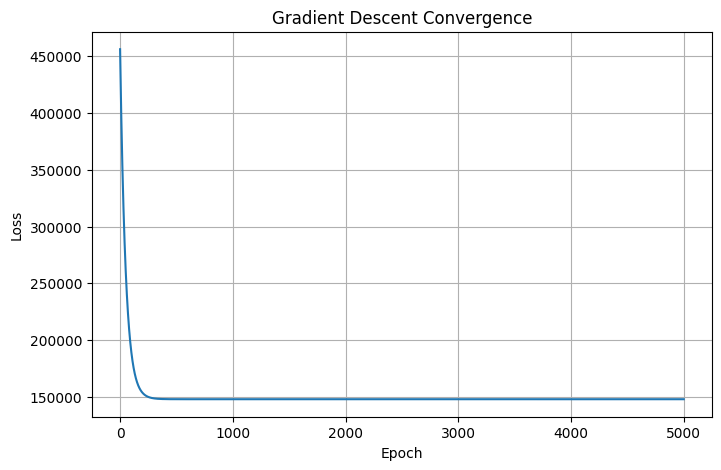

In [12]:
#Plot Gradient Descent
plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Gradient Descent Convergence")

plt.grid(True)
plt.show()

In [13]:
y_pred_gd = X_test_gd @ theta

print(y_pred_gd[:10])

[[1120.32559368]
 [1277.62385563]
 [1318.40488651]
 [ 820.29372367]
 [ 514.4359921 ]
 [1143.6290399 ]
 [1239.75575553]
 [ 389.17996869]
 [1105.7609398 ]
 [ 811.55493134]]


In [14]:
#Calculate MAE
mae_gd = mean_absolute_error(y_test, y_pred_gd)

print("MAE:", mae_gd)

MAE: 402.89373708711645


In [15]:
#Calculate MSE
mse_gd = mean_squared_error(y_test, y_pred_gd)

print("MSE:", mse_gd)

MSE: 293180.0061746947


In [16]:
#Calculate RMSE
rmse_gd = np.sqrt(mse_gd)

print("RMSE:", rmse_gd)

RMSE: 541.4609922927917


In [17]:
#Calculate R²
r2_gd = r2_score(y_test, y_pred_gd)

print("R²:", r2_gd)

R²: 0.2963334847635001


In [19]:
print("Gradient Descent Linear Regression")
print("MAE  :", mae_gd)
print("MSE  :", mse_gd)
print("RMSE :", rmse_gd)
print("R²   :", r2_gd)

Gradient Descent Linear Regression
MAE  : 402.89373708711645
MSE  : 293180.0061746947
RMSE : 541.4609922927917
R²   : 0.2963334847635001


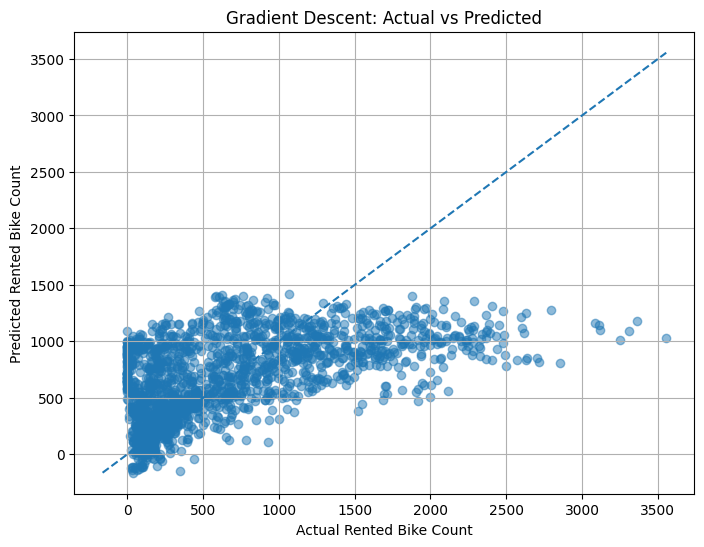

In [20]:
#Actual vs Predicted graph
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_gd, alpha=0.5)

minimum = min(y_test.min(), y_pred_gd.min())
maximum = max(y_test.max(), y_pred_gd.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Rented Bike Count")
plt.ylabel("Predicted Rented Bike Count")
plt.title("Gradient Descent: Actual vs Predicted")

plt.grid(True)
plt.show()

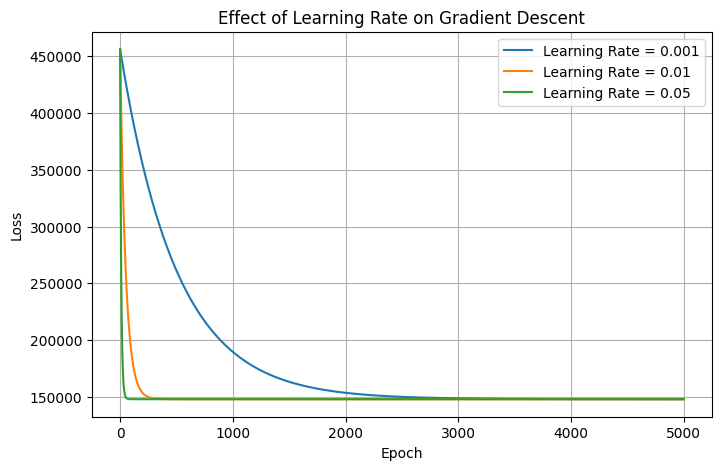

In [21]:
#Analyze different learning rates
learning_rates = [0.001, 0.01, 0.05]

plt.figure(figsize=(8, 5))

for lr in learning_rates:

    theta_test = np.zeros((2, 1))
    losses = []

    for i in range(5000):

        predictions = X_train_gd @ theta_test

        error = predictions - y_train

        loss = np.mean(error ** 2) / 2
        losses.append(loss)

        gradient = (X_train_gd.T @ error) / len(y_train)

        theta_test = theta_test - lr * gradient

    plt.plot(losses, label=f"Learning Rate = {lr}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Learning Rate on Gradient Descent")
plt.legend()
plt.grid(True)
plt.show()